# Aprendizaje Automatizado - Tarea 2
## Ejercicio 3
### Elizabeth Ríos Alvarado

# Predicción de juegos
Un club del juego de Go recopiló los resultados de varias partidas entre diferentes jugadores, almacenados en el archivo `partidas_entrenamiento.txt`, con el objetivo de predecir el resultado de partidas futuras, ejemplos de las cuales se encuentran en el archivo `partidas_prueba.txt`. Los archivos `partidas_entrenamiento.txt` y `partidas_prueba.txt` contienen 3 columnas: la primera
corresponde al identificador del jugador A, la segunda al identificador del jugador B y la tercera es el resultado de la partida (1 si ganó el jugador A o 0 si ganó el jugador B). En el club hay un total de D jugadores, por lo que cada identificador es un número entero entre 1 y D. La predicción del resultado de un juego se puede plantear como un problema de clasificación: dados 2 jugadores (A y
B) se requiere predecir si A ganó (y = 1) o si fue B (y = 0).

Realice los siguientes ejercicios:


1.   Entrena y evalúa un clasificador bayesiano ingenuo. Al ser un modelo generativo (modela
la probabilidad conjunta $P (\mathbf{x}, y)$), es posible generar partidas artificiales con los parámetros calculados. Genera nuevas partidas que sigan la distribución modelada.
2.   Entrena y evalúa un clasificador de regresión logística. Debido a que ambos atributos son categóricos, es necesario cambiar la codificación. Explica el procedimiento y la lógica de la codificación que realizaste. Visualiza los valores de los parámetros del modelo de regresión logística y discute qué interpretación tendrían de acuerdo a la codificación realizada. Grafica las curvas ROC y de precisión-exhaustividad y reporta sus áreas bajo la curva.
3.   Compara el clasificador bayesiano ingenuo y regresión logística en este problema. ¿Qué ventajas y desventajas tienen los modelos entrenados? ¿Qué pasaría si se entrena el clasificador bayesiano ingenuo con los vectores recodificados o si se entrena un modelo de regresión logística usando los vectores de entrada originales? ¿Consideras que las presuposiciones de cada clasificador son apropiadas para los datos del problema? ¿Para este tipo de problemas cuál de los dos recomendarías y por qué?
4.   Deriva la regla de actualización para el algoritmo del descenso por gradiente de un clasificador donde $\hat{y} = sigm(\theta^\top \mathbf{x})$ y la función de pérdida sea
$$
E(\theta) = \frac{1}{2} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2.
$$
Discute las diferencias entre este clasificador y el de regresión logística y el efecto que tendría en el comportamiento del algoritmo del descenso por gradiente cambiar la función de pérdida por
$$
E(\theta) = \frac{1}{2n} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2.
$$


## Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

## Ejercicio 1

### Datos

In [ ]:
DataEntrenamiento = pd.read_csv("/content/drive/MyDrive/20252/AprendizajeAutomatizado/Tarea2/Ejercicio3/partidas_entrenamiento.csv")
DataPrueba = pd.read_csv("/content/drive/MyDrive/20252/AprendizajeAutomatizado/Tarea2/Ejercicio3/partidas_prueba.csv")
DataEntrenamiento.head()

,id_blancas,id_negras,ganador
0,3,4,1
1,7,8,1
2,40,10,1
3,16,17,1
4,8,18,1


In [ ]:
DataPrueba.head()

,id_blancas,id_negras,ganador
0,35,43,1
1,45,9,0
2,55,106,0
3,35,43,1
4,35,43,1


In [ ]:
DataEntrenamiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_blancas  319 non-null    int64
 1   id_negras   319 non-null    int64
 2   ganador     319 non-null    int64
dtypes: int64(3)
memory usage: 7.6 KB


In [ ]:
DataPrueba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_blancas  115 non-null    int64
 1   id_negras   115 non-null    int64
 2   ganador     115 non-null    int64
dtypes: int64(3)
memory usage: 2.8 KB


### Solución

In [ ]:
## CAMBIO DE DATOS PARA BAYES INGENUO ##
# Los modelos no aceptan directamente texto o números que representen categorías sin una codificación adecuada.
# Que los id sean números, no implica que tengan un orden. Por lo que hay que tratarlos como categorías, no como valores numéricos.

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(pd.concat([DataEntrenamiento['id_blancas'], DataEntrenamiento['id_negras'], DataPrueba['id_blancas'], DataPrueba['id_negras']]))
DataEntrenamiento['A'] = encoder.transform(DataEntrenamiento['id_blancas'])
DataEntrenamiento['B'] = encoder.transform(DataEntrenamiento['id_negras'])
DataPrueba['A'] = encoder.transform(DataPrueba['id_blancas'])
DataPrueba['B'] = encoder.transform(DataPrueba['id_negras'])
DataEntrenamiento.head()

,id_blancas,id_negras,ganador,A,B
0,3,4,1,2,3
1,7,8,1,6,7
2,40,10,1,39,9
3,16,17,1,15,16
4,8,18,1,7,17


In [ ]:
DataPrueba.head()

,id_blancas,id_negras,ganador,A,B
0,35,43,1,34,42
1,45,9,0,44,8
2,55,106,0,54,105
3,35,43,1,34,42
4,35,43,1,34,42


In [ ]:
## ENTRENAMIENTO DEL CLASIFICADOR BAYES INGENUO ##
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X_train = DataEntrenamiento[['A', 'B']]
y_train = DataEntrenamiento['ganador']

X_test = DataPrueba[['A', 'B']]
y_test = DataPrueba['ganador']

nb = CategoricalNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {acc:.3f}")

Precisión del modelo: 0.696


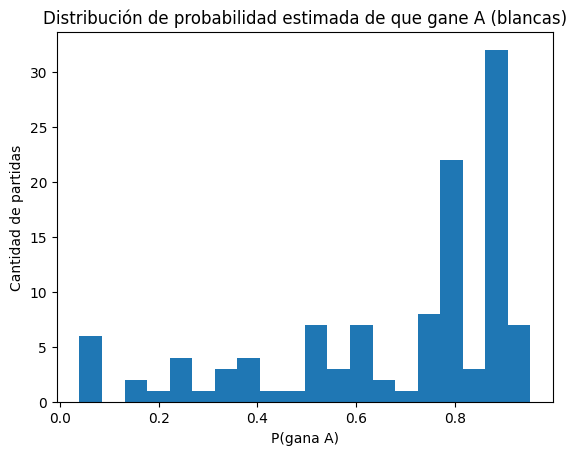

In [ ]:
## VISUALIZACIÓN
# Probabilidades aprendidas por Bayes Ingenuo
# Probabilidad de que gane el jugador A dado A y B
probs = nb.predict_proba(X_test)
plt.hist(probs[:,1], bins=20)
plt.title("Distribución de probabilidad estimada de que gane A (blancas)")
plt.xlabel("P(gana A)")
plt.ylabel("Cantidad de partidas")
plt.show()

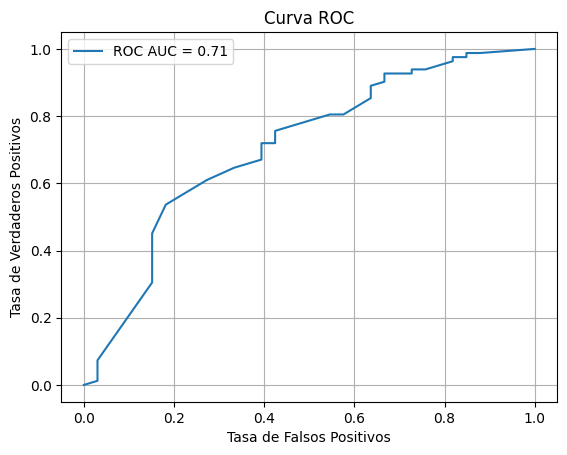

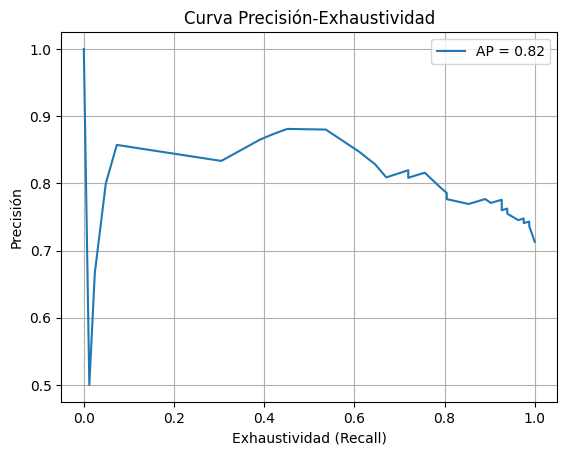

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Probabilidades
y_scores = nb.predict_proba(X_test)[:, 1]

# ROC
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_scores)
roc_auc_nb = roc_auc_score(y_test, y_scores)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc_nb = average_precision_score(y_test, y_scores)

# Gráfica ROC
plt.figure()
plt.plot(fpr_nb, tpr_nb, label=f"ROC AUC = {roc_auc_nb:.2f}")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

# Gráfica Precisión-Exhaustividad
plt.figure()
plt.plot(recall, precision, label=f"AP = {pr_auc_nb:.2f}")
plt.xlabel("Exhaustividad (Recall)")
plt.ylabel("Precisión")
plt.title("Curva Precisión-Exhaustividad")
plt.legend()
plt.grid(True)
plt.show()

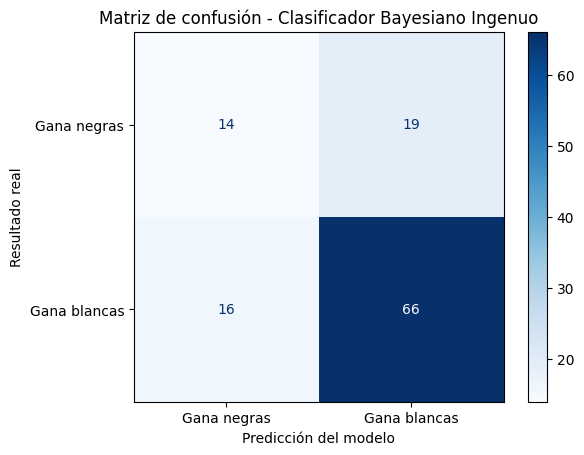

In [ ]:
## VISUALIZACIÓN
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=["Gana negras", "Gana blancas"])

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Clasificador Bayesiano Ingenuo")
plt.xlabel("Predicción del modelo")
plt.ylabel("Resultado real")
plt.show()

In [ ]:
## PARTIDAS ARTIFICIALES ##
# Se obtiene la distribución empírica de jugadores
# Cuántas veces aparece cada jugador como blancas y como negras
dist_A = DataEntrenamiento['A'].value_counts(normalize=True).sort_index()
dist_B = DataEntrenamiento['B'].value_counts(normalize=True).sort_index()

# Se generan combinaciones (A, B) según esas distribuciones
n_partidas = 100  # número de partidas

A_gen = np.random.choice(dist_A.index, size=n_partidas, p=dist_A.values)
B_gen = np.random.choice(dist_B.index, size=n_partidas, p=dist_B.values)

# Se predicen resultados usando el clasificador entrenado
X_gen = pd.DataFrame({'A': A_gen, 'B': B_gen})
y_gen = nb.predict(X_gen)

# Se revierten los IDs codificados a los originales
X_gen['id_blancas'] = encoder.inverse_transform(X_gen['A'])
X_gen['id_negras'] = encoder.inverse_transform(X_gen['B'])
X_gen['ganador'] = y_gen

# Se borran las columnas A y B
X_gen = X_gen.drop(columns=['A', 'B'])

# Se muestran las partidas generadas
print("Partidas artificiales generadas:")
X_gen.head(10)

Partidas artificiales generadas:


,id_blancas,id_negras,ganador
0,27,131,1
1,3,101,1
2,8,105,1
3,4,61,0
4,80,35,0
5,42,101,0
6,122,43,1
7,12,23,0
8,37,43,1
9,96,18,1


### Discusión

## Ejercicio 2

### Datos

In [ ]:
DataEntrenamiento = pd.read_csv("/content/drive/MyDrive/20252/AprendizajeAutomatizado/Tarea2/Ejercicio3/partidas_entrenamiento.csv")
DataPrueba = pd.read_csv("/content/drive/MyDrive/20252/AprendizajeAutomatizado/Tarea2/Ejercicio3/partidas_prueba.csv")

### Solución

In [ ]:
## CAMBIOS EN LOS DATOS PARA REGRESIÓN LOGÍSTICA ##
from sklearn.preprocessing import OneHotEncoder

# Se obtiene el número total de jugadores
D = max(DataEntrenamiento[['id_blancas', 'id_negras']].max().max(), DataPrueba[['id_blancas', 'id_negras']].max().max())

# Función para codificar partidas
def CodificarPartidas(Data, D):
    X = np.zeros((len(Data), D))
    for i, (a, b) in enumerate(zip(Data['id_blancas'], Data['id_negras'])):
        X[i, a - 1] = 1    # jugador A
        X[i, b - 1] = -1   # jugador B
    return X

# Se crea unas nuevas bases de datos
X_train = CodificarPartidas(DataEntrenamiento, D)
X_test = CodificarPartidas(DataPrueba, D)
y_train = DataEntrenamiento['ganador'].values
y_test = DataPrueba['ganador'].values

In [ ]:
## ENTRENAMIENTO REGRESIÓN LOGÍSTICA ##
from sklearn.linear_model import LogisticRegression

# Entrenar modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Evaluación
acc = modelo.score(X_test, y_test)
print(f"Precisión del modelo: {acc:.3f}")

Precisión del modelo: 0.704


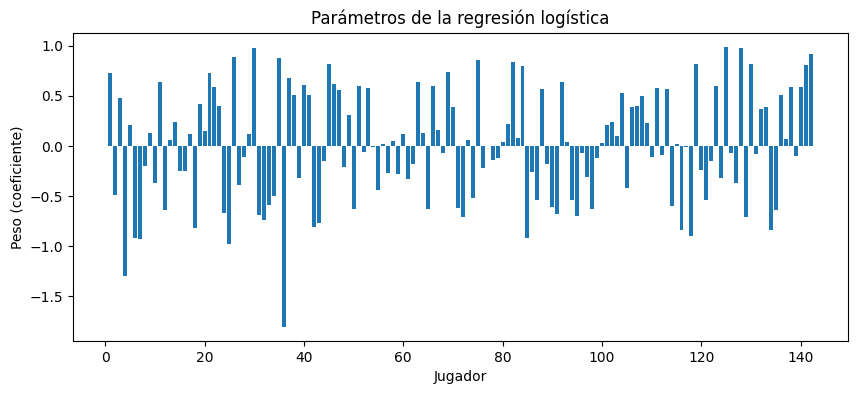

In [ ]:
coeficientes = modelo.coef_[0]

plt.figure(figsize=(10, 4))
plt.bar(range(1, D + 1), coeficientes)
plt.xlabel("Jugador")
plt.ylabel("Peso (coeficiente)")
plt.title("Parámetros de la regresión logística")
plt.show()

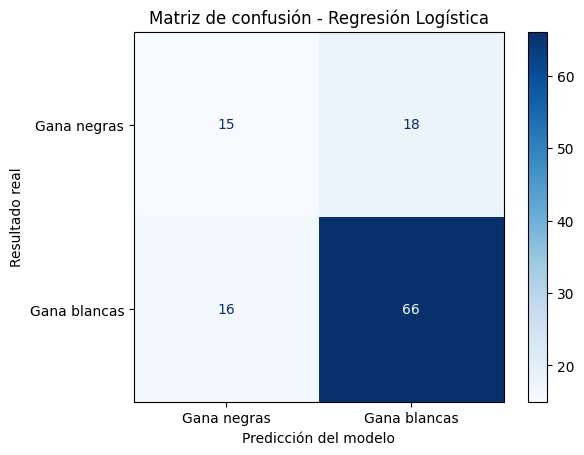

In [ ]:
## VISUALIZACIÓN ##
# Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Gana negras", "Gana blancas"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción del modelo")
plt.ylabel("Resultado real")
plt.show()

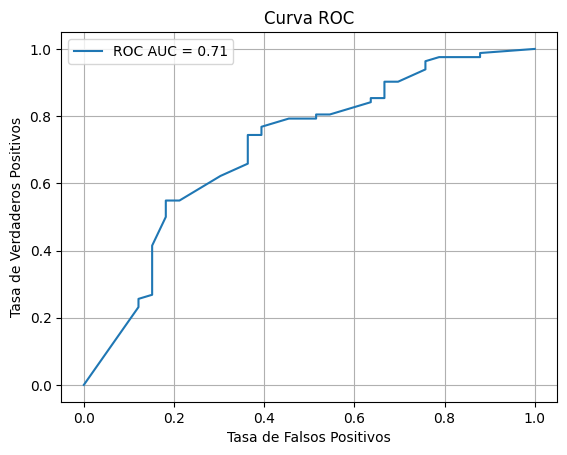

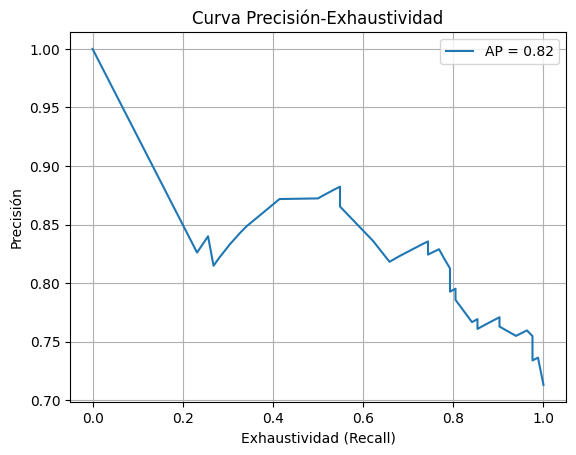

In [ ]:
## CURVAS ROC Y PRECISIÓN-EXHAUSTIVIDAD - REGRESIÓN LOGÍSTICA ##
from sklearn.metrics import (
    roc_curve, 
    roc_auc_score, 
    precision_recall_curve, 
    average_precision_score
)

# Se obtienen las probabilidades de clase positiva (ganador = jugador id_blancas)
y_scores_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

# Cálculo de la curva ROC
fpr_logistico, tpr_logistico, _ = roc_curve(y_test, y_scores_logistico)
roc_auc_logistico = roc_auc_score(y_test, y_scores_logistico)

# Cálculo de la curva Precisión-Exhaustividad
precision_logistico, recall_logistico, _ = precision_recall_curve(y_test, y_scores_logistico)
ap_logistico = average_precision_score(y_test, y_scores_logistico)

# Gráfica de la curva ROC
plt.figure()
plt.plot(fpr_logistico, tpr_logistico, label=f"AUC = {roc_auc_logistico:.2f}")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC - Modelo de Regresión Logística")
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de la curva Precisión-Exhaustividad
plt.figure()
plt.plot(recall_logistico, precision_logistico, label=f"AP = {ap_logistico:.2f}")
plt.xlabel("Exhaustividad (Recall)")
plt.ylabel("Precisión")
plt.title("Curva Precisión-Exhaustividad - Modelo de Regresión Logística")
plt.legend()
plt.grid(True)
plt.show()


### Discusión

## Ejercicio 3: Comparación
* ¿Qué ventajas y desventajas tienen los modelos entrenados?
* ¿Qué pasaría si se entrena el clasificador bayesiano ingenuo con los vectores recodificados?
* ¿Y si se entrena regresión logística con los vectores de entrada originales?
* ¿Las presuposiciones de cada clasificador son apropiadas para los datos?
* ¿Cuál recomendarías y por qué?



En la siguiente tabla se pueden apreciar las pocas diferencias que hubieron entre los resultados de ambos procedimientos. Básicamente puede observarse que la Regresión Logística es ligeramente mejor en precisión.


|    | Modelo              |   Precisión |   ROC AUC |   Precisión promedio (AP) |
|----|---------------------|-------------|-----------|---------------------------|
|  0 | Regresión logística |       0.704 |      0.71 |  0.82 |
|  1 | Bayes Ingenuo       |       0.696 |      0.71 |  0.82 |

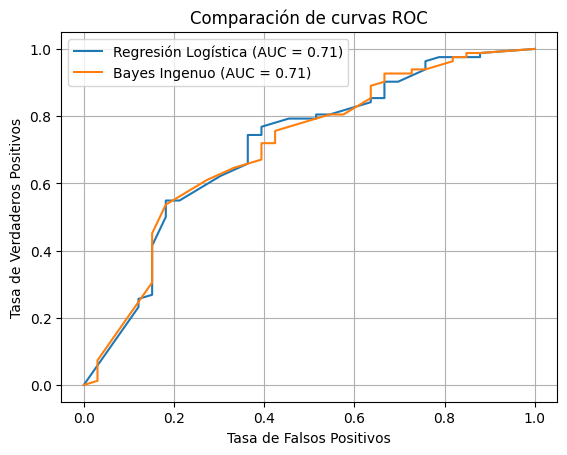

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {roc_auc:.2f})")
plt.plot(fpr_nb, tpr_nb, label=f"Bayes Ingenuo (AUC = {roc_auc_nb:.2f})")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparación de curvas ROC")
plt.legend()
plt.grid(True)
plt.show()

### ¿Qué ventajas y desventajas tienen los modelos entrenados?

#### Bayes Ingenuo
Es un modelo generativo, es decir, se modela la probabilidad conjunta $P(x, y) = P(x \mid y) \cdot P(y)$. Esto significa que el modelo aprende cómo se distribuyen los datos en cada clase y luego utiliza la regla de Bayes para estimar la probabilidad de que una partida pertenezca a cada clase.

**Ventajas**
1.   Se pueden generar datos artificiales. Como el modelo aprende la distribución de los datos en cada clase, se puede utilizar para crear nuevas partidas sintéticas que sigan la misma distribución.
2.   Es simple y rápido de entrenar, pues es muy eficiente computacionalmente y suele funcionar bien incluso con pocas muestras de entrenamiento o en problemas con mucho ruido.
3.   En general funciona bien aunque asuma que hay independencia entre atributos y eso no sea completamente cierto.

**Desventajas**
1.   En este caso, la presencia del jugador A en una partida no es independiente de la del jugador B, lo que rompe la suposición fundamental del modelo.
2.   Sus probabilidades pueden estar mal calibradas. Aunque Bayes Ingenuo puede predecir correctamente la clase, las probabilidades que genera no siempre reflejan con precisión la verdadera incertidumbre.
3.   Menor capacidad de interpretar relaciones complejas: el modelo no puede capturar interacciones entre atributos, lo que limita su expresividad.

---

#### Regresión Logística
Es un modelo discriminativo, es decir, modela directamente la probabilidad condicional $ P(y \mid x)$. A diferencia de los modelos generativos, no intenta modelar cómo se ven los datos de cada clase por separado, sino que se enfoca en encontrar una frontera de decisión que separe bien las clases.

**Ventajas**
1.   Mejora el desempeño predictivo. Al enfocarse en la clasificación, generalmente suele tener mejor precisión y métricas ROC/AP que modelos generativos cuando se tienen suficientes datos. (Esto no pasó aquí xd)
2.   Produce coeficientes interpretables. Los parámetros del modelo indican qué tan influyente es cada jugador en el resultado de la partida. Esto permite analizar la “habilidad” relativa aprendida por el modelo.
3.   Las predicciones están bien calibradas: las probabilidades que genera suelen representar bien la confianza del modelo en sus decisiones.

**Desventajas**
1.   Requiere codificación adecuada. Como los atributos son categóricos, es necesario transformarlos en vectores numéricos antes de usar el modelo.
2.   No se puede usar para generar datos. Al no modelar la distribución de los datos, no permite simular partidas nuevas.
3.   Supone una relación lineal en los log-odds. Si la relación entre los atributos y el resultado no es lineal, el modelo puede tener dificultades para capturarla sin transformaciones adicionales.

### ¿Qué pasaría si se entrena el clasificador bayesiano ingenuo con los vectores recodificados?

Si se entrenara a Bayes Ingenuo con los vectores recodificados, habría problemas con la suposición que se hace de "no correlación". Dado que los jugadores juegan unos contra otros, están correlacionados, pero el modelo funciona razonablemento.

###  ¿Y si se entrena regresión logística con los vectores de entrada originales?

Si los ids se mantuvieran igual, generarían un orden que no tiene sentido en este contexto, pues el hecho de que tu id sea 10, no te hace mejor que aquella con id 09. Esto haría que se tengan resultados difíciles de interpretar o incorrectos.

### ¿Las presuposiciones de cada clasificador son apropiadas para los datos?
**Bayes Ingenuo**


No es exactamente apropiado, poruqe Bayes Ingenuo asume independencia entre atributos pero aún es útil.

**Regresión Logística**

Sí se ajusta bien al problema, ya que la codificación convierte los jugadores en atributos lineales en la probabilidad log-odds.

### ¿Cuál recomendarías y por qué?

Ambos modelos tienen un rendimiento muy similar pero creo que lo mejor sería usar la *Regresión Logística* porque se ajusta mejor a la estructura de los datos, sus parámetros permiten interpretar la habilidad de cada jugador y funciona bien. Bayes Ingenuo sólo sería más útil para hacer partidas artificiales.

## Ejercicio 4

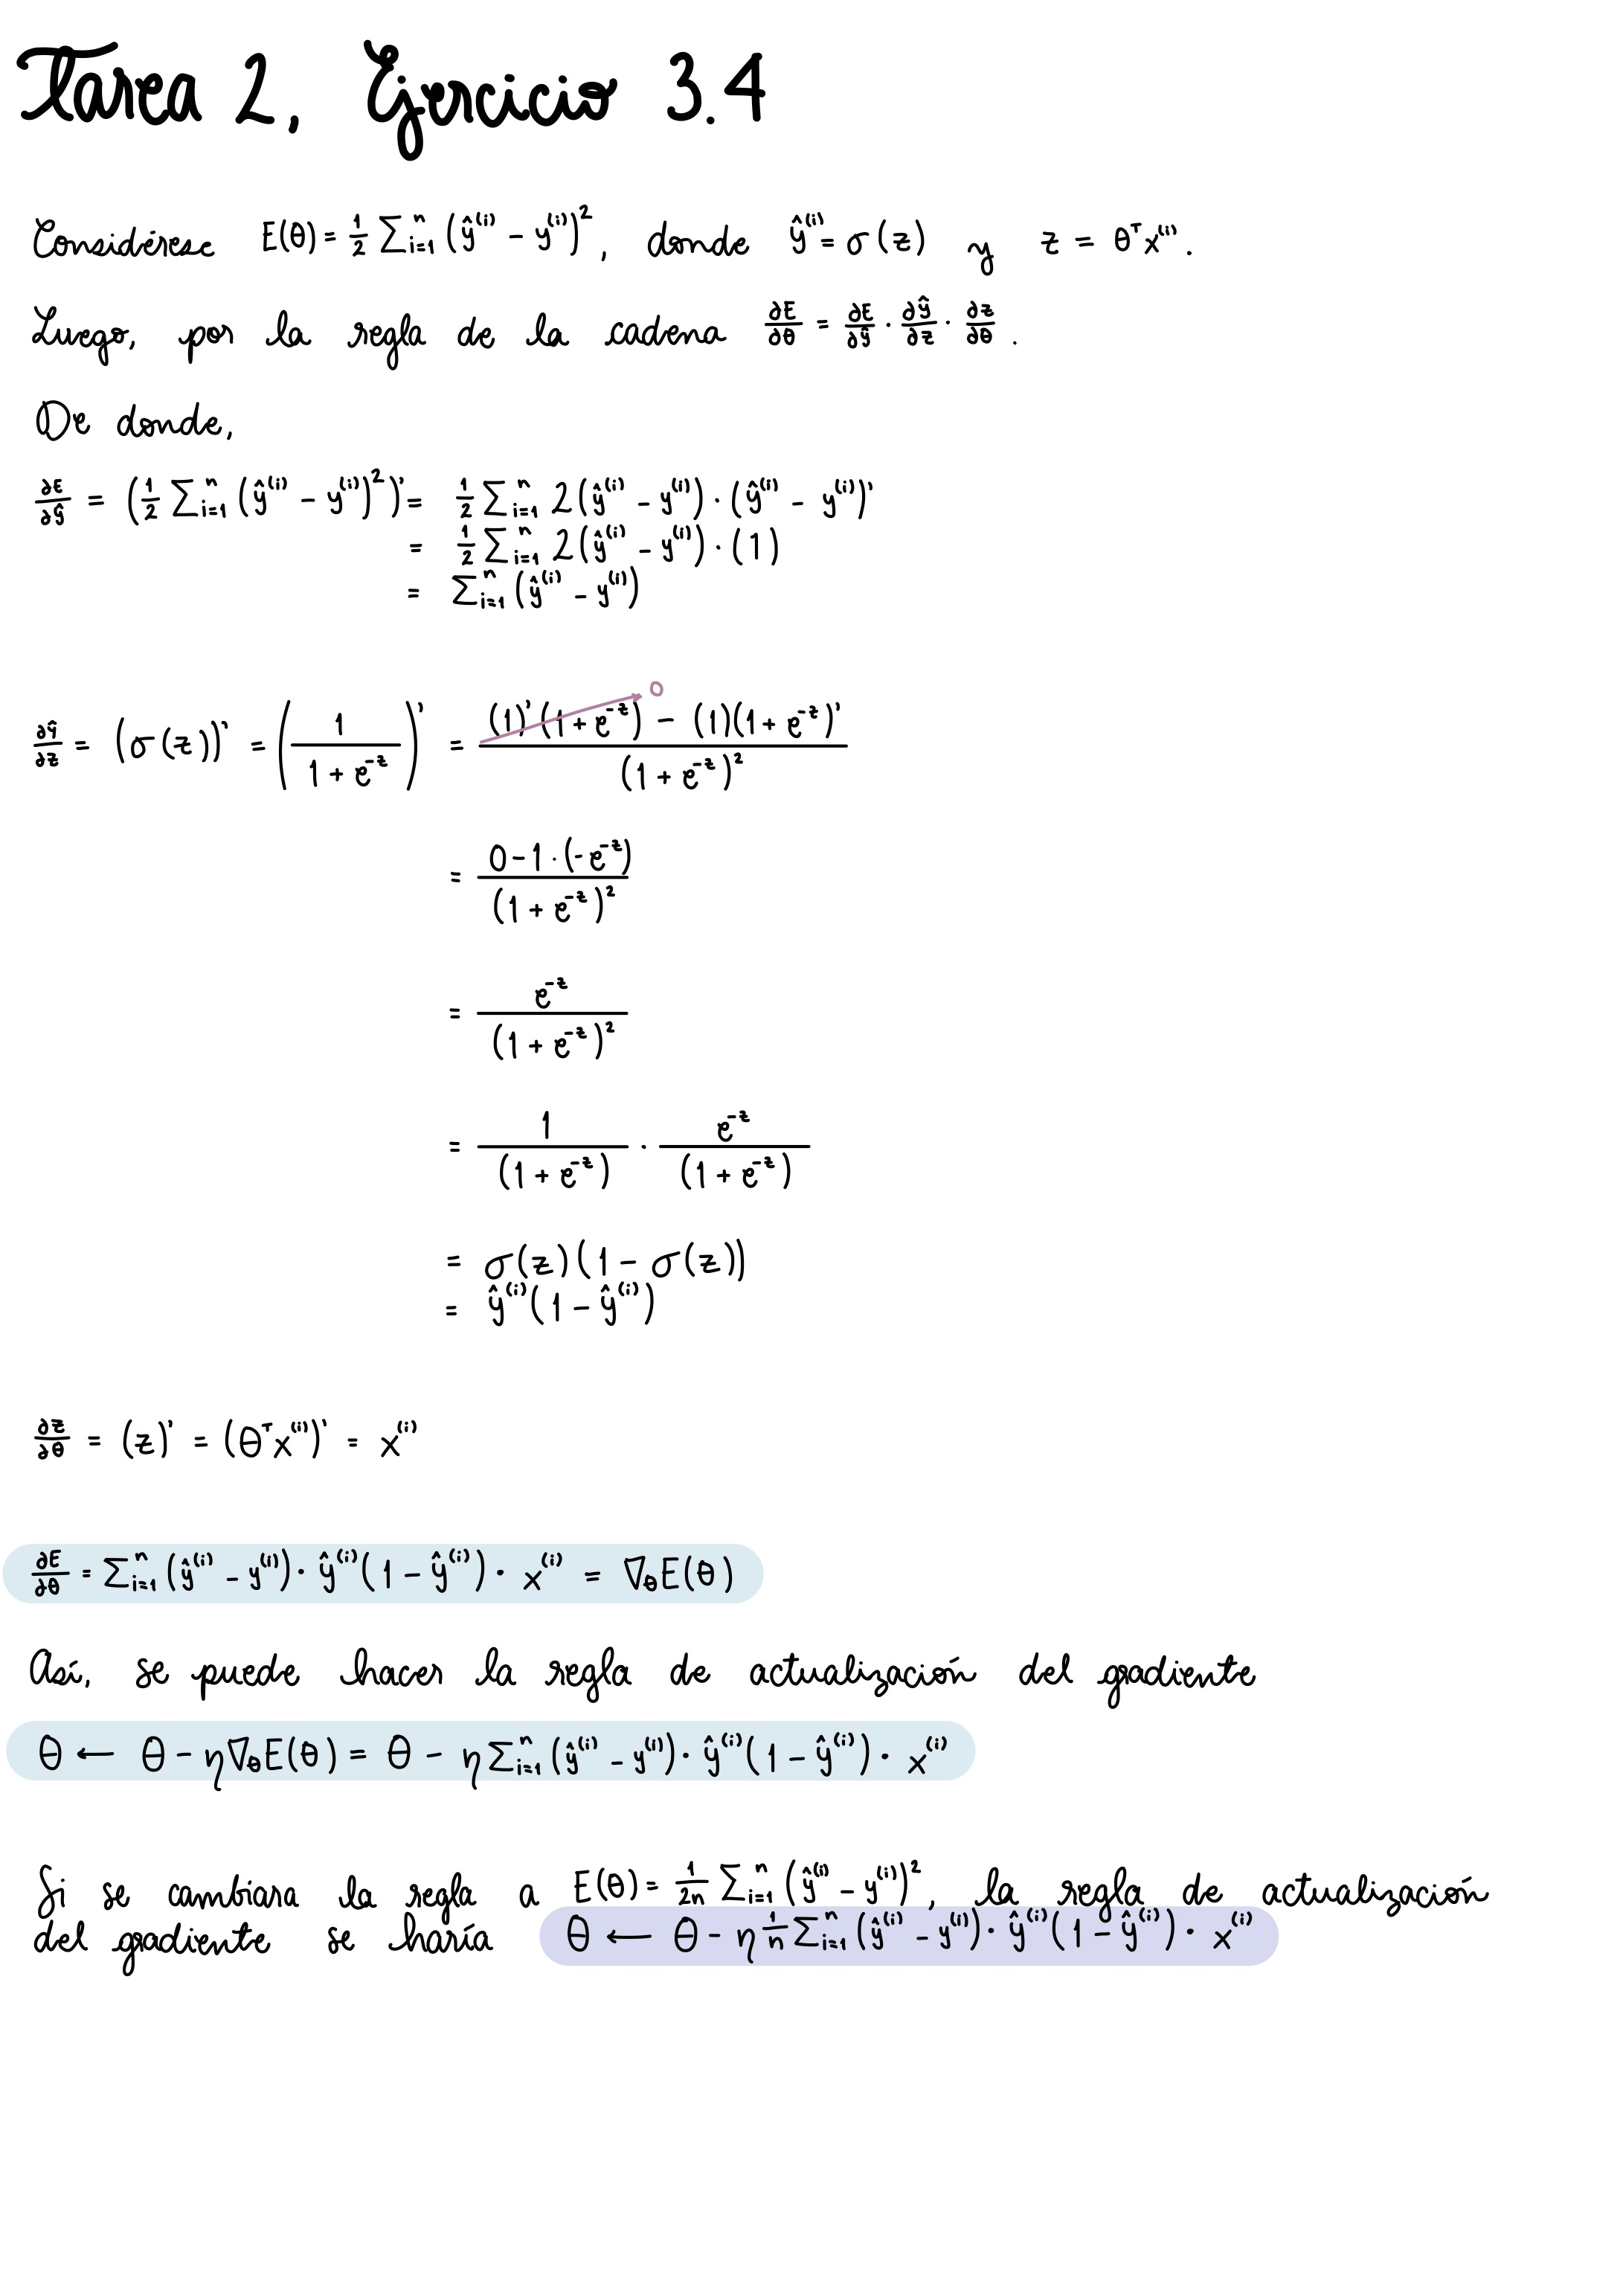

Esto hace que la pérdida no dependa del tamaño del conjunto de datos y facilita la elección de una tasa de aprendizaje más estable.

---

### Diferencias entre este clasificador y el de regresión logística
En regresión logística se utiliza una función de pérdida diferente, conocida como entropía cruzada:
  $$
  E(\theta) = - \sum_{i=1}^n \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
  $$
Esta pérdida penaliza más fuertemente las malas predicciones y tiene mejores propiedades para clasificación binaria.
Usar el error cuadrático medio con activación sigmoide puede causar problemas en la convergencia del algoritmo.